# Team
- Stefanos Panteli UC1065916<br>
spante01@ucy.ac.cy

- Evangelia Krigkou UC1067400<br>
ekrigk01@ucy.ac.cy

- Rafael Chrysanthou UC1064747<br>
rchrys03@ucy.ac.cy


GitHub: [https://github.com/stefanosPanteli/EPL445](https://github.com/stefanosPanteli/EPL445)

# Part C

# Installs

In [1]:
!pip install opencv-python
!pip install matplotlib
!pip install numpy

ERROR: Could not find a version that satisfies the requirement math (from versions: none)
ERROR: No matching distribution found for math


# Imports

In [2]:
import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import numpy as np
import math

# Functions & Constants

In [3]:
def plot_all(I, mask, magnitude_spectrum, I_inv, title: str):
    magnitude_spectrum_filterred = magnitude_spectrum * mask

    plt.subplot(221), plt.imshow(I, cmap= 'gray')
    plt.title('Input Image')
    plt.subplot(222), plt.imshow(mask, cmap= 'gray')
    plt.title(f'{title} Mask')
    plt.subplot(223), plt.imshow(magnitude_spectrum_filterred, cmap= 'gray'), plt.colorbar(fraction= 0.045, pad= 0.05)
    plt.title('Magnitude Spectrum\n(after Applying Mask)')
    plt.subplot(224), plt.imshow(I_inv, cmap= 'gray')
    plt.title('Inverse FFT')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(2,2))
    plt.imshow(magnitude_spectrum)
    plt.imshow(mask, alpha= 0.1)
    plt.title('Magnitude Spectrum\nand Mask on Top')
    plt.show()
    print()

# 1 & 2

In [4]:
def _read_resize_gray(index: str) -> cv2.Mat:
  '''
  `_read_resize_gray_bw` reads an image, resizes it 4 times, converts it to grayscale, and converts it to black and white.

  `Args:`
    - `index`: The index of the image. A character

  `Returns:`
    - A tuple containing the resized image, the grayscale image, and the black and white image.
  '''
  image = cv2.imread(f'input/dermatological_sample_{index.upper()}.png')
  # Resize
  image = cv2.resize(image, None, fx=4, fy=4, interpolation= cv2.INTER_LINEAR)
  # Convert to grayscale
  image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
  return image_gray

image1 = _read_resize_gray('A')
image2 = _read_resize_gray('B')
image3 = _read_resize_gray('C')
image4 = _read_resize_gray('D')

# 3

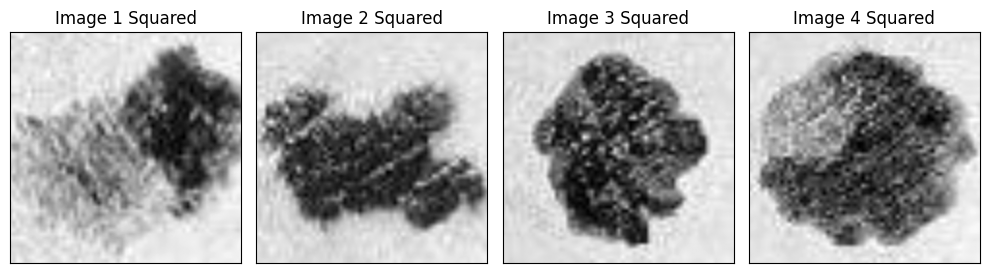

In [5]:
N = 240
# Square the Images
image1_sq = image1[0:N,62:62+N]
image2_sq = image2[:N,42:42+N]
image3_sq = image3[0:N,42:42+N]
image4_sq = image4[10:10+N,52:52+N]

# Plot the images
plt.figure(figsize=(10, 3))
plt.subplot(141), plt.imshow(image1_sq, cmap= 'gray'), plt.title('Image 1 Squared')
plt.xticks([]), plt.yticks([])
plt.subplot(142), plt.imshow(image2_sq, cmap= 'gray'), plt.title('Image 2 Squared')
plt.xticks([]), plt.yticks([])
plt.subplot(143), plt.imshow(image3_sq, cmap= 'gray'), plt.title('Image 3 Squared')
plt.xticks([]), plt.yticks([])
plt.subplot(144), plt.imshow(image4_sq, cmap= 'gray'), plt.title('Image 4 Squared')
plt.xticks([]), plt.yticks([])
plt.tight_layout()
plt.show()

# 4

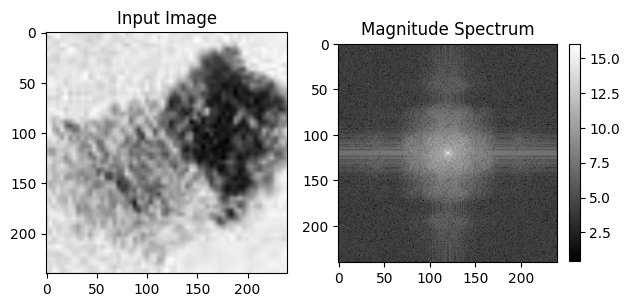

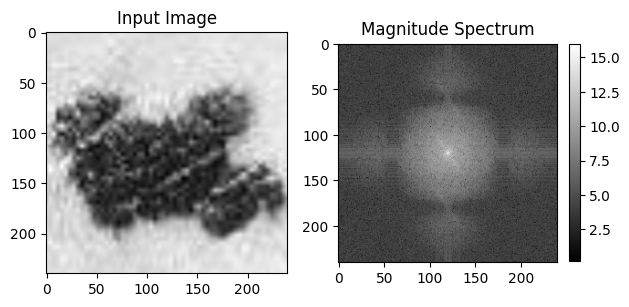

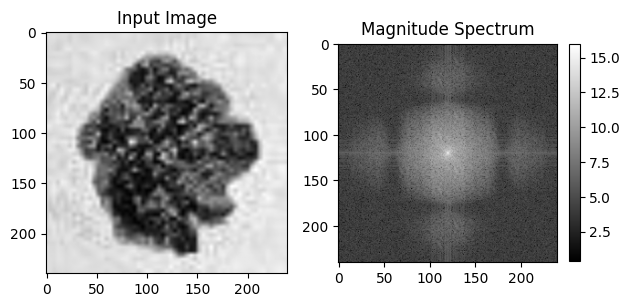

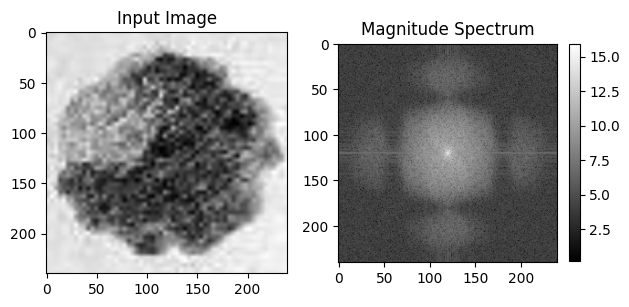

In [6]:
images_fft = []
for I in (image1_sq, image2_sq, image3_sq, image4_sq):
  # Apply FFT transformation
  I_fft = np.fft.fft2(I)
  I_shift = np.fft.fftshift(I_fft)
  magnitude_spectrum = np.log(1 + np.abs(I_shift))
  images_fft.append((I_shift, magnitude_spectrum))

  # Show all 3
  plt.subplot(121), plt.imshow(I, cmap= 'gray')
  plt.title('Input Image')
  plt.subplot(122), plt.imshow(magnitude_spectrum, cmap= 'gray'),
  plt.colorbar(fraction= 0.045, pad= 0.05)
  plt.title('Magnitude Spectrum')
  plt.tight_layout()
  plt.show()

image1_fft,       image2_fft,       image3_fft,       image4_fft       = [i[0] for i in images_fft]
image1_magnitude, image2_magnitude, image3_magnitude, image4_magnitude = [i[1] for i in images_fft]

# 5 & 6

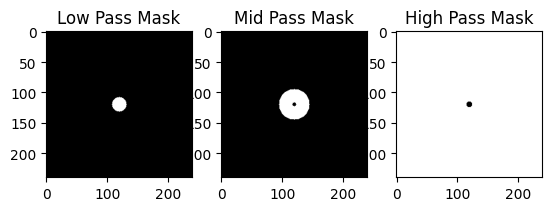

In [7]:
# Get shape
rows, cols = (N, N)
crow, ccol = rows/2 , cols/2
crow = int(crow)
ccol = int(ccol)

# Define radiuses
low_radius: int = 12
mid_radius_outer: int = 25
mid_radius_inner: int = 3
high_radius: int = 5

# Circle Low Pass Mask
low_mask = np.zeros((rows, cols), np.uint8)
# low_mask[ # Square
#    crow - low_radius : crow + low_radius,
#    ccol - low_radius : ccol + low_radius
# ] = 1
for i in range(0, rows):
  for j in range(0, cols):
    if (i - crow)**2 + (j - ccol)**2 <= low_radius**2:
      low_mask[i, j] = 1

# Circle Mid Pass Mask
mid_mask = np.zeros((rows, cols), np.uint8)
# mid_mask[ # Square
#    crow - mid_radius_outer : crow + mid_radius_outer,
#    ccol - mid_radius_outer : ccol + mid_radius_outer
# ] = 1
# mid_mask[ # Square
#    crow - mid_radius_inner : crow + mid_radius_inner,
#    ccol - mid_radius_inner : ccol + mid_radius_inner
# ] = 0
for i in range(0, rows):
  for j in range(0, cols):
    if (i - crow)**2 + (j - ccol)**2 <= mid_radius_outer**2:
      mid_mask[i, j] = 1
for i in range(0, rows):
  for j in range(0, cols):
    if (i - crow)**2 + (j - ccol)**2 <= mid_radius_inner**2:
      mid_mask[i, j] = 0

# Circle High Pass Mask
high_mask = np.zeros((rows, cols), np.uint8)
# high_mask = np.ones((rows, cols), np.uint8)
# high_mask[ # Square
#    crow - high_radius : crow + high_radius,
#    ccol - high_radius : ccol + high_radius
# ] = 0
for i in range(0, rows):
  for j in range(0, cols):
    if (i - crow)**2 + (j - ccol)**2 >= high_radius**2:
      high_mask[i, j] = 1

# Showing Masks
plt.subplot(131), plt.imshow(low_mask, cmap= 'gray')
plt.title('Low Pass Mask')
plt.subplot(132), plt.imshow(mid_mask, cmap= 'gray')
plt.title('Mid Pass Mask')
plt.subplot(133), plt.imshow(high_mask, cmap= 'gray')
plt.title('High Pass Mask')
plt.show()


# Apply the Masks
image1_low = image1_fft * low_mask
image1_mid = image1_fft * mid_mask
image1_high = image1_fft * high_mask

image2_low = image2_fft * low_mask
image2_mid = image2_fft * mid_mask
image2_high = image2_fft * high_mask

image3_low = image3_fft * low_mask
image3_mid = image3_fft * mid_mask
image3_high = image3_fft * high_mask

image4_low = image4_fft * low_mask
image4_mid = image4_fft * mid_mask
image4_high = image4_fft * high_mask


# 7

In [8]:
def _ifft(masked):
  ishift = np.fft.ifftshift(masked)
  ifft = np.fft.ifft2(ishift)
  return np.real(ifft)

# InverseFFT
image1_low_inv = _ifft(image1_low)
image1_mid_inv = _ifft(image1_mid)
image1_high_inv = _ifft(image1_high)

image2_low_inv = _ifft(image2_low)
image2_mid_inv = _ifft(image2_mid)
image2_high_inv = _ifft(image2_high)

image3_low_inv = _ifft(image3_low)
image3_mid_inv = _ifft(image3_mid)
image3_high_inv = _ifft(image3_high)

image4_low_inv = _ifft(image4_low)
image4_mid_inv = _ifft(image4_mid)
image4_high_inv = _ifft(image4_high)

# 8

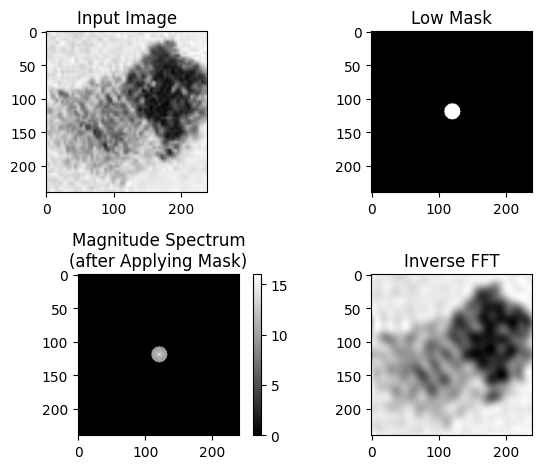

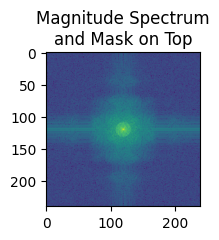

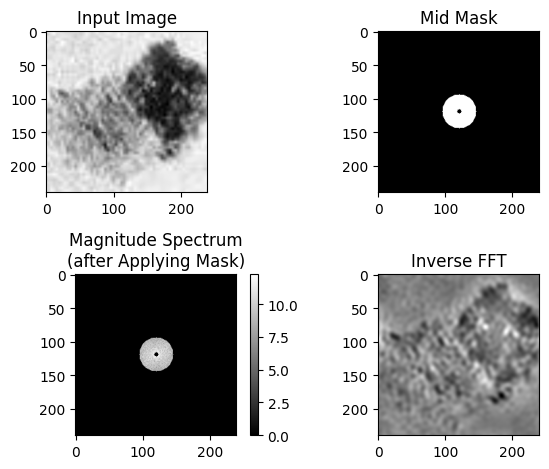

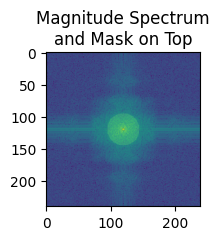

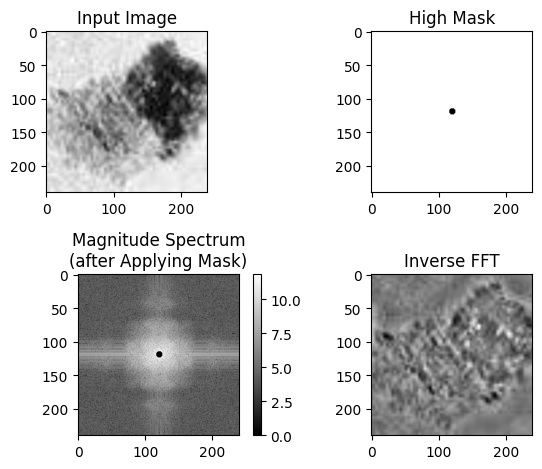

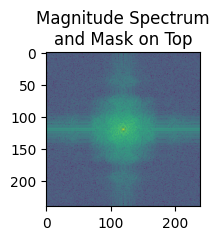

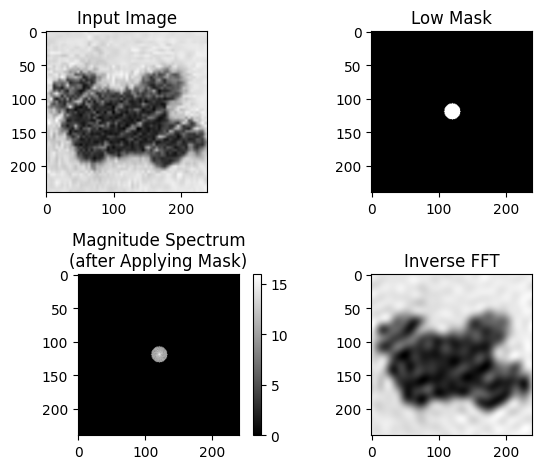

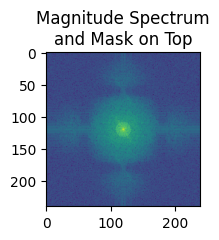

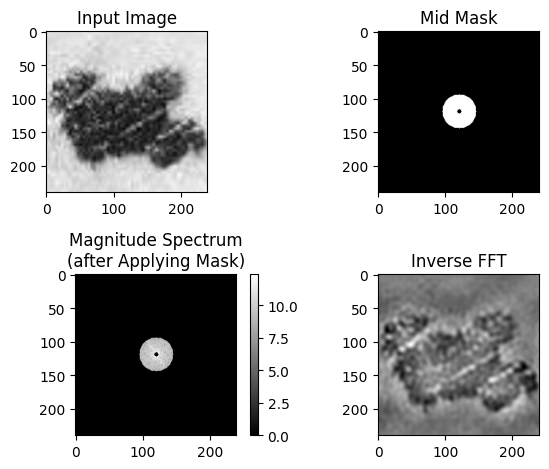

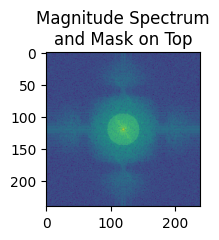

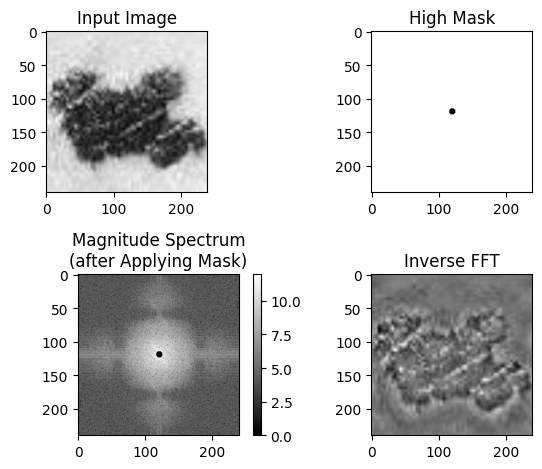

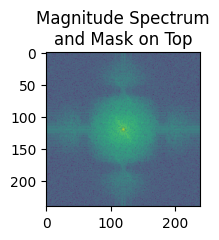

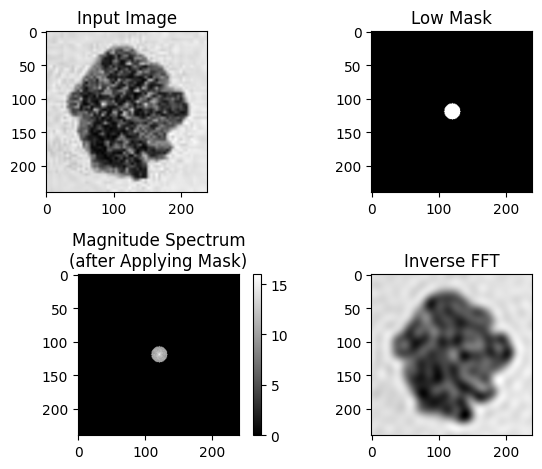

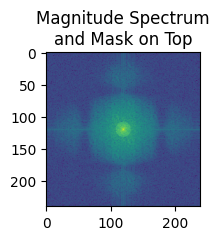

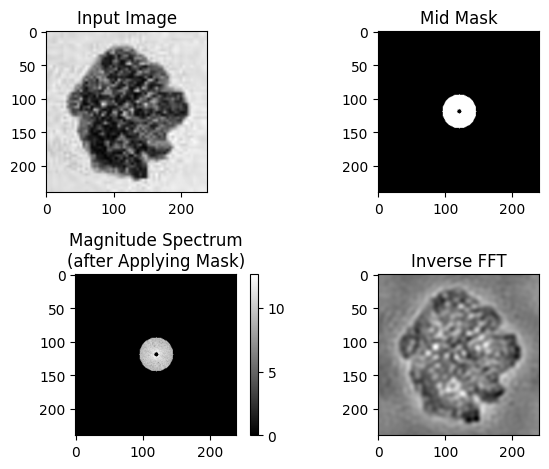

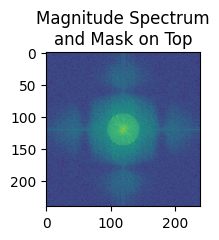

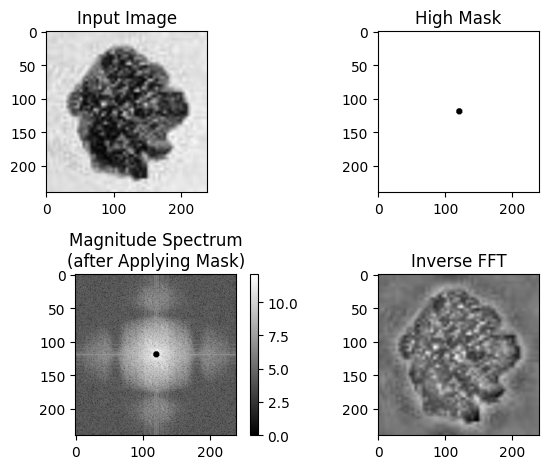

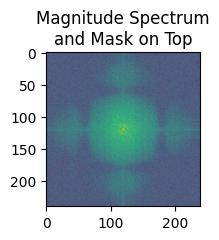

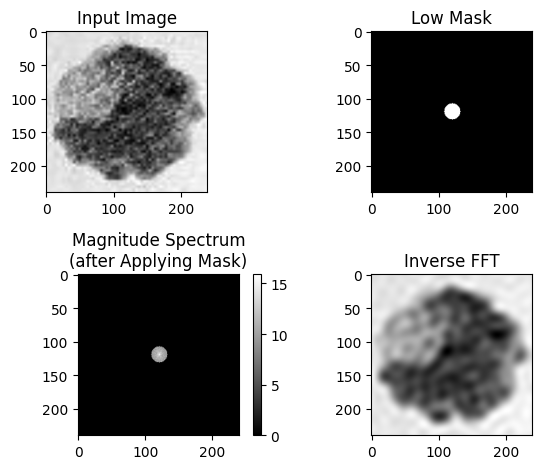

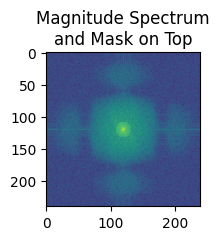

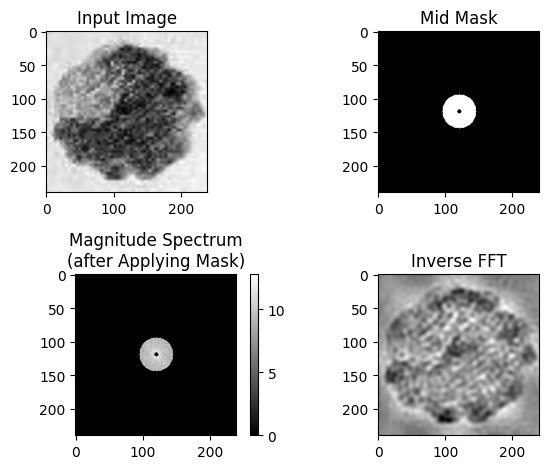

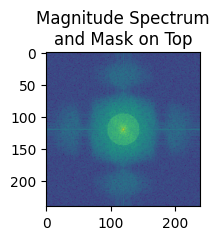

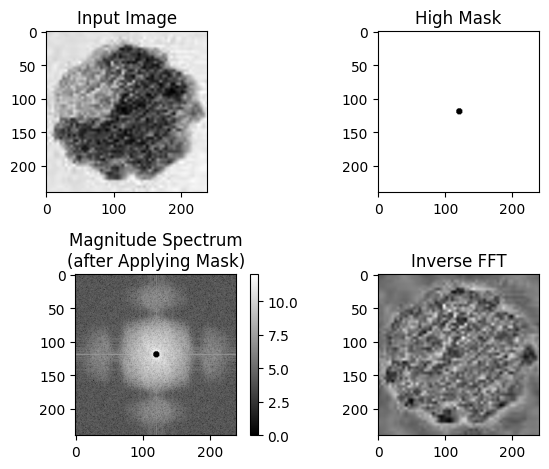

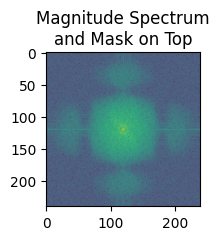

In [9]:
plot_all(image1_sq, low_mask, image1_magnitude, image1_low_inv, 'Low')
plot_all(image1_sq, mid_mask, image1_magnitude, image1_mid_inv, 'Mid')
plot_all(image1_sq, high_mask, image1_magnitude, image1_high_inv, 'High')

plot_all(image2_sq, low_mask, image2_magnitude, image2_low_inv, 'Low')
plot_all(image2_sq, mid_mask, image2_magnitude, image2_mid_inv, 'Mid')
plot_all(image2_sq, high_mask, image2_magnitude, image2_high_inv, 'High')

plot_all(image3_sq, low_mask, image3_magnitude, image3_low_inv, 'Low')
plot_all(image3_sq, mid_mask, image3_magnitude, image3_mid_inv, 'Mid')
plot_all(image3_sq, high_mask, image3_magnitude, image3_high_inv, 'High')

plot_all(image4_sq, low_mask, image4_magnitude, image4_low_inv, 'Low')
plot_all(image4_sq, mid_mask, image4_magnitude, image4_mid_inv, 'Mid')
plot_all(image4_sq, high_mask, image4_magnitude, image4_high_inv, 'High')